In [2]:
import xarray as xr
import numpy as np

import torch
import einops
import itertools
import torch_harmonics
import math

import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.colors as mcolors
import matplotlib.gridspec as gridspec


from utils.config import *
from utils.dataset import NinoData

from omegaconf import OmegaConf
from dataclasses import replace

In [3]:
cfg_file = OmegaConf.load('mae.yaml')
config = MTMConfig.from_omegaconf(cfg_file['defaults'])

In [4]:
dataset = NinoData(config.trainer.godas_path, config.data).dataset

In [5]:

nino4 = dataset['temp_ocn_0a'].sel(time = slice('1981-12', '1984-06'), lon=slice(160, 210), lat=slice(-5, 5)).mean(dim=['lon', 'lat'])

In [6]:
sample = dataset.sel(time = slice('1982-01', '1985-01', 12))
len(sample.time)

4

In [94]:
dataset = NinoData(config.trainer.godas_path, config.data).dataset

var_labels = ['SSTa', 'T150a', 'TAUXa']
var_names = ['temp_ocn_0a', 'temp_ocn_14a', 'tauxa']
kwargs = [{'vmin': -3, 'vmax': 3}, {'vmin': -3, 'vmax': 3}, {'vmin': -1, 'vmax': 1}]

cm = mpl.cm.bwr
cm.set_bad('slategray')

In [113]:
sample = dataset.sel(time = slice('1982-01', '1985-01', 12))

nv = len(var_labels)
nt = len(sample.time)
nlat, nlon = len(sample.lat), len(sample.lon)
nh, nw = nlat // 8, nlon // 8

a, b = 2, 3

u = np.random.random_sample(size = (nv, nt, nh, nw))
u = einops.rearrange(np.log(u), 'v t h w -> (v t h w)')

u_t = np.random.random_sample((nt))
u_t = einops.repeat(np.log(u_t), 't -> (v t h w)', v = nv, t = nt, h = nh, w = nw)

u_v = np.random.random_sample((nv,))
u_v = einops.repeat(np.log(u_v), 'v -> (v t h w)', v = nv, t = nt, h = nh, w = nw)

u_hw = np.random.random_sample((a, b))
u_hw = einops.repeat(np.log(u_hw), 'a b -> (v t h a w b)', v = nv, t = nt, h = nh // a, w = nw // b)

K = 256

In [114]:
def make_masked_plot(prior):
    mask = K > np.argsort(np.argsort(prior))
    mask = einops.repeat(mask, '(nv nt nh nw) ->  nv nt (nh ph) (nw pw)', ph = 8, pw = 8, nv = nv, nt = nt, nh = nh, nw = nw)
    fig, axs = plt.subplots(nv,nt, figsize = (nt * 5, nv * 3))
    for i, var in enumerate(var_names):
        subsample = sample[var].where(mask[i])
        for t in range(nt):
            plt.sca(axs[i, t])        
            axs[i, t].set_box_aspect(0.5)
            subsample.isel(time = t).plot(**kwargs[i], cmap = cm, add_colorbar = False)
            axs[i, t].set_title(f"{np.datetime64(sample.isel(time=t).time.values, 'M')}", fontsize=11, fontweight='bold')
        axs[i, 0].set_ylabel(var_labels[i], fontsize=11, fontweight='bold', labelpad=8)

    plt.tight_layout()

    plt.show()

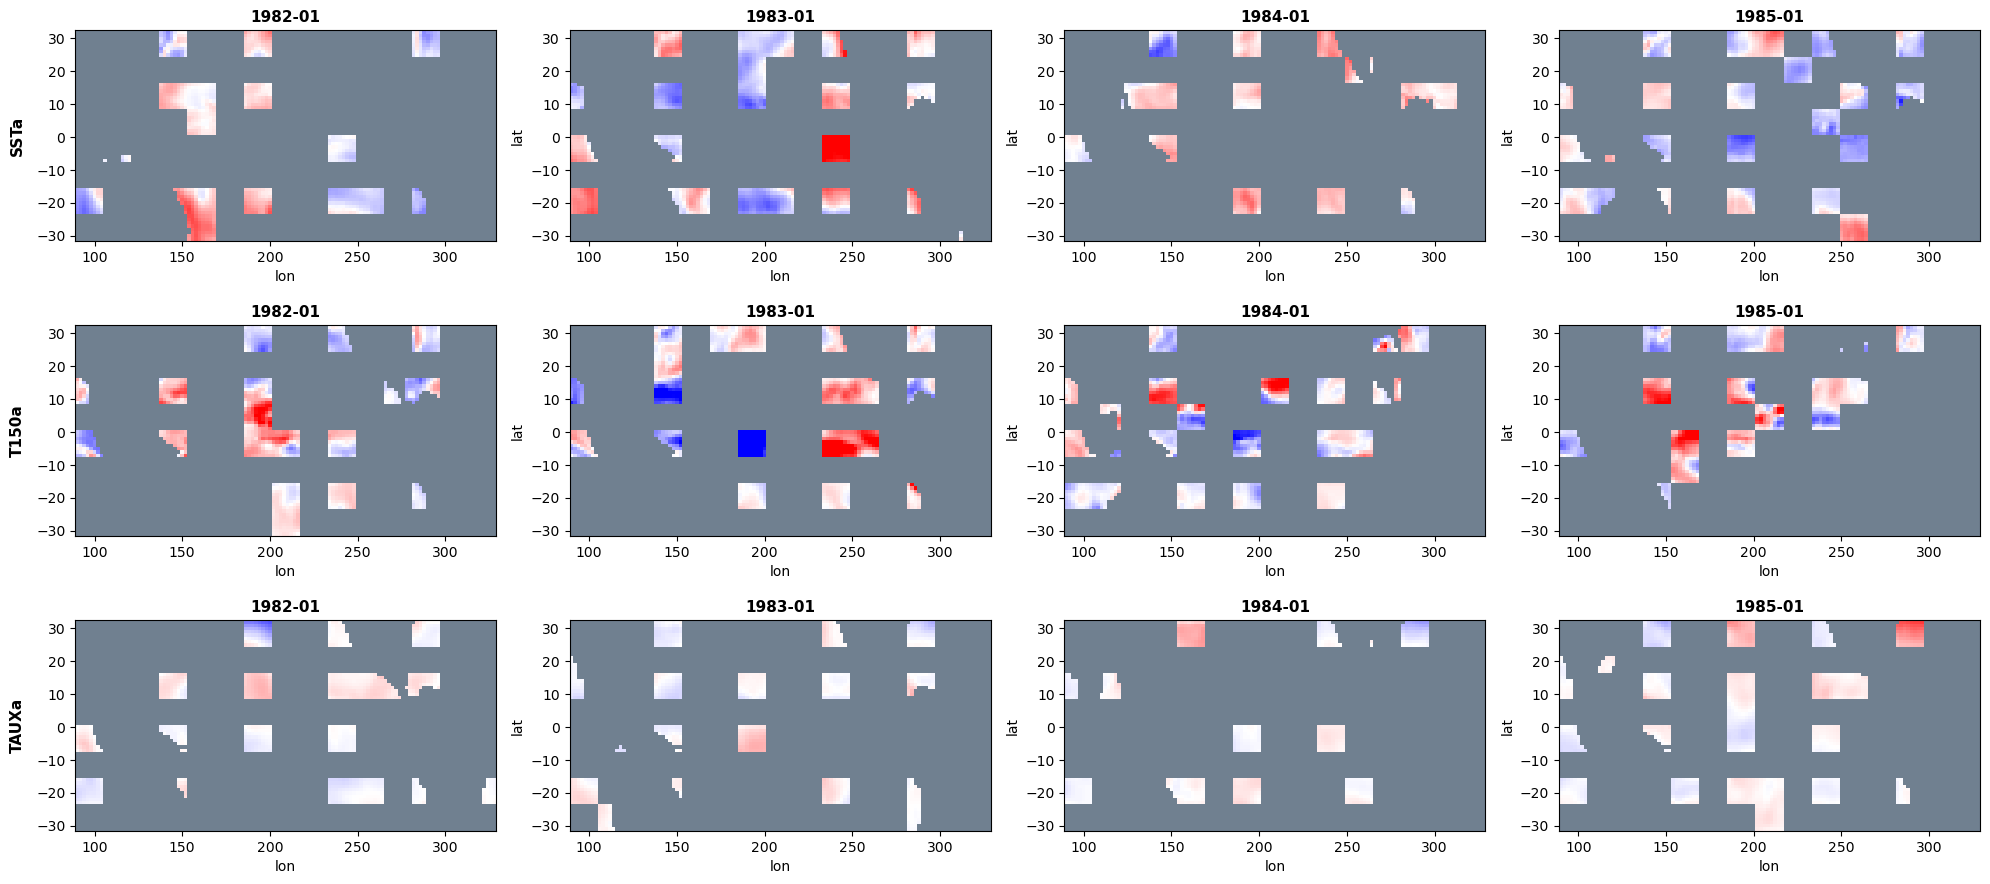

In [130]:
make_masked_plot(4 * u_hw + u)

In [127]:
tasks = {
    't': u + u_t * 3,
    'base': u,
}

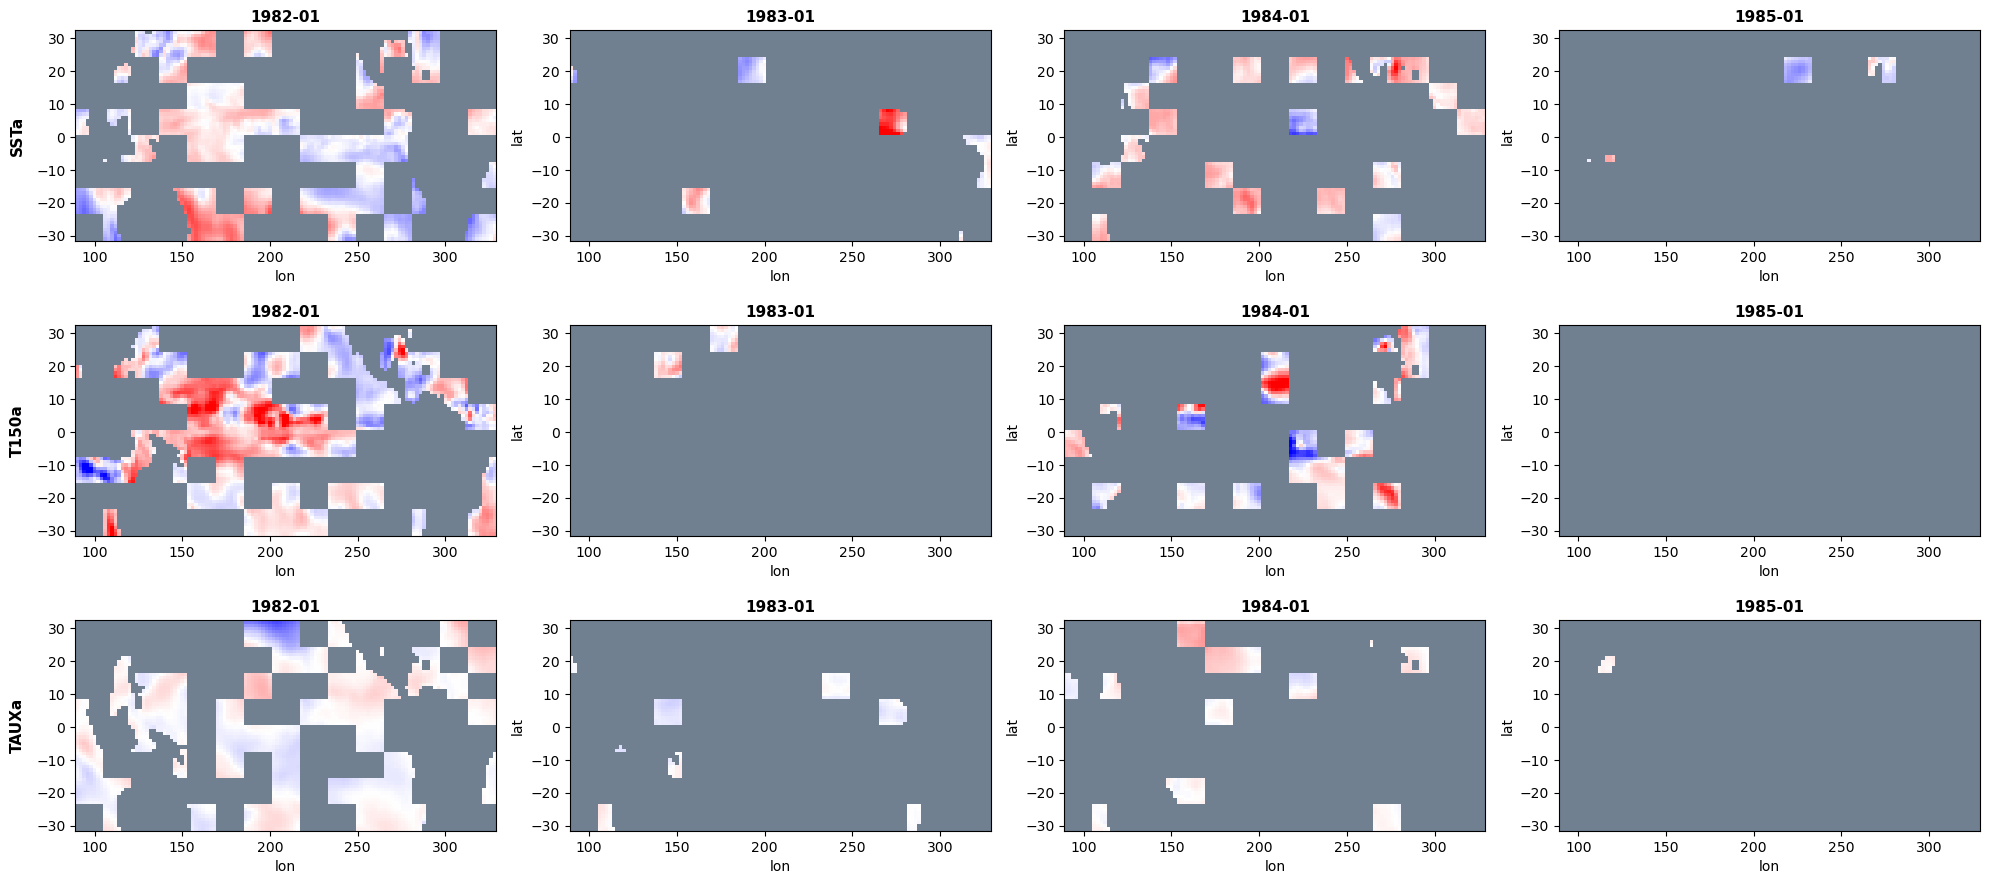

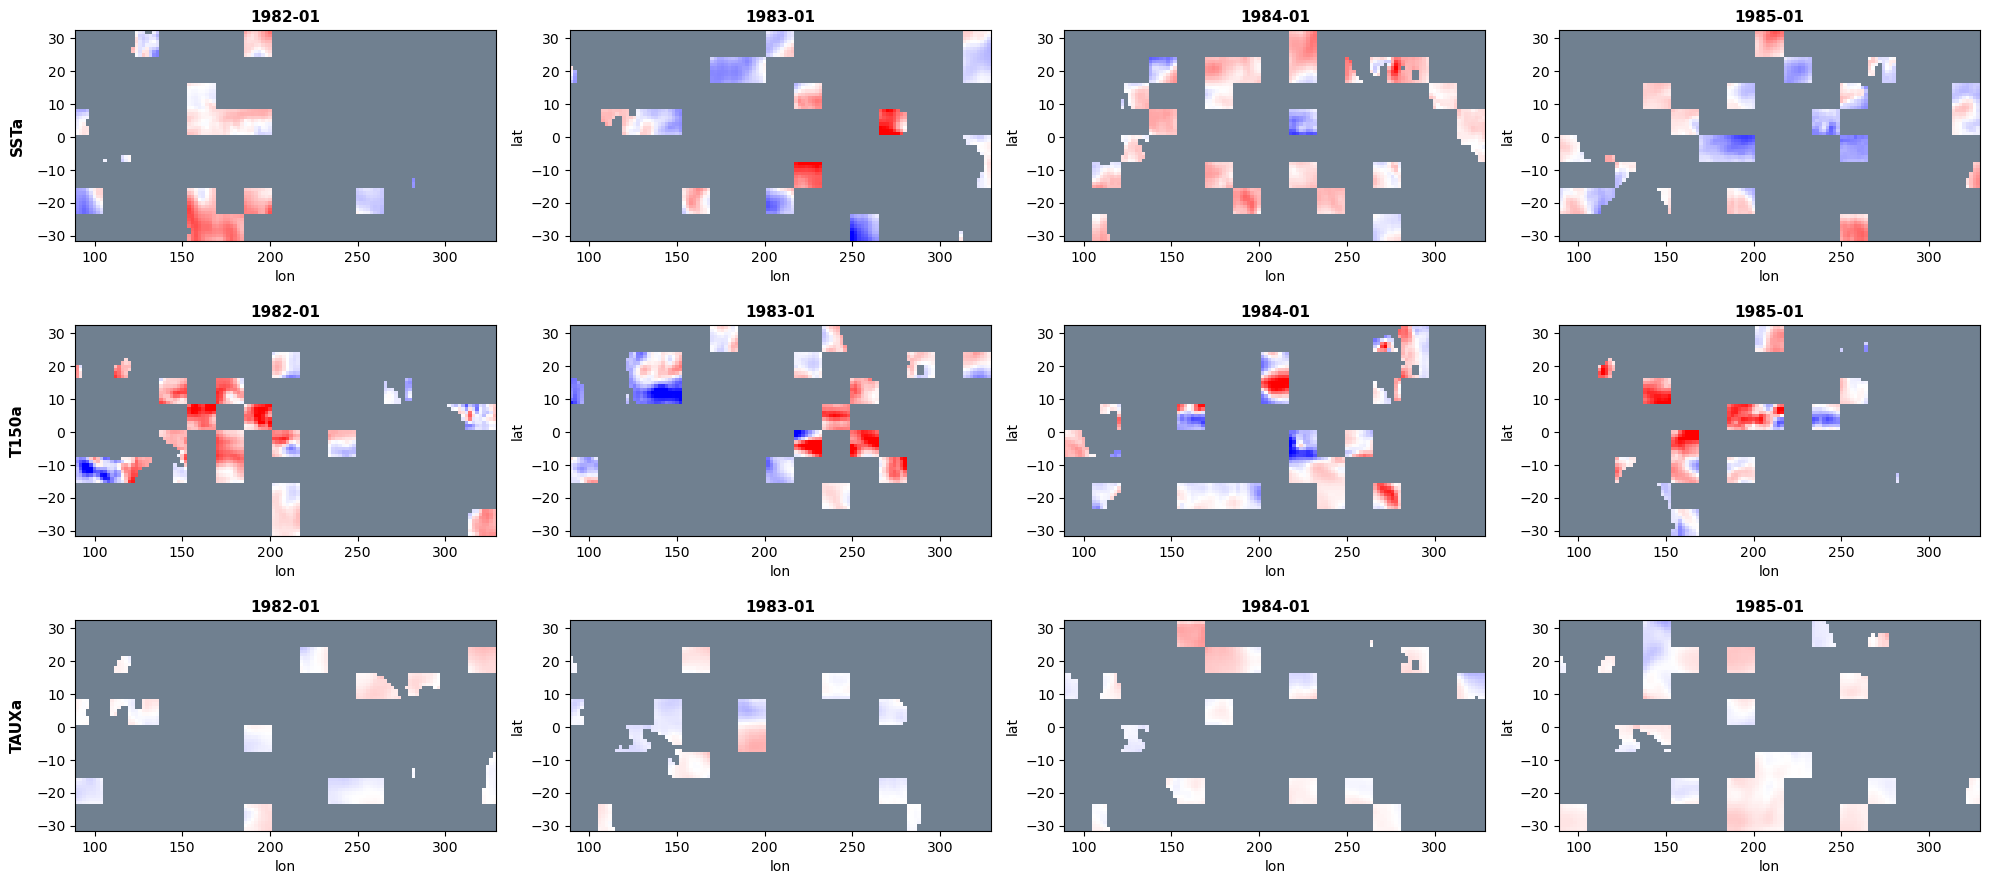

In [128]:
for label, task in tasks.items():
    make_masked_plot(task)